In [1]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from spark_utils import get_spark

spark = get_spark("QualityReport")
df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv("data/gold/dados_gold.csv")
    .cache()
)
record_count = df.count()
column_count = len(df.columns)
print("=" * 50)
print("RELATÓRIO DE QUALIDADE DE DADOS")
print("=" * 50)
print(f"Total de registros: {record_count} | Total de colunas: {column_count}")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/11/10 20:30:05 WARN Utils: Your hostname, Davis-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.200.60.101 instead (on interface en0)
25/11/10 20:30:05 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/10 20:30:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/10 20:30:07 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/11/10 20:30:07 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/11/10 20:30:07 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
25/11/10 20:30:07 WA

RELATÓRIO DE QUALIDADE DE DADOS
Total de registros: 10476 | Total de colunas: 24


In [2]:
print("1. COMPLETUDE DOS DADOS")
print("-" * 50)
filled_counts_row = df.select([F.count(F.col(c)).alias(c) for c in df.columns]).collect()[0]
filled_counts = filled_counts_row.asDict()
completude_por_coluna = {}
for coluna, preenchidos in filled_counts.items():
    percentual = (preenchidos / record_count * 100) if record_count else 0
    completude_por_coluna[coluna] = percentual
    print(f" {coluna}: {percentual:.2f}%")

total_celulas = record_count * column_count
celulas_preenchidas = sum(filled_counts.values())
completude_geral = (celulas_preenchidas / total_celulas * 100) if total_celulas else 0
print(f"Completude Geral: {completude_geral:.2f}%")


1. COMPLETUDE DOS DADOS
--------------------------------------------------
 CODIGO_CLIENTE: 100.00%
 UF: 100.00%
 IDADE: 100.00%
 ESCOLARIDADE: 100.00%
 ESTADO_CIVIL: 100.00%
 QT_FILHOS: 100.00%
 CASA_PROPRIA: 100.00%
 QT_IMOVEIS: 100.00%
 VL_IMOVEIS: 100.00%
 OUTRA_RENDA: 100.00%
 OUTRA_RENDA_VALOR: 100.00%
 TEMPO_ULTIMO_EMPREGO_MESES: 100.00%
 TRABALHANDO_ATUALMENTE: 100.00%
 ULTIMO_SALARIO: 100.00%
 QT_CARROS: 100.00%
 VALOR_TABELA_CARROS: 100.00%
 SCORE: 100.00%
 DATA_UPLOAD: 100.00%
 ARQUIVO_FONTE: 100.00%
 RENDA_TOTAL: 100.00%
 DATA_TRATAMENTO: 100.00%
 FAIXA_ETARIA: 100.00%
 TEM_FILHOS: 100.00%
 CATEGORIA_RENDA: 100.00%
Completude Geral: 100.00%


In [3]:
print("2. UNICIDADE DOS DADOS")
print("-" * 50)
distinct_count = df.dropDuplicates().count()
duplicatas = record_count - distinct_count
unicidade = ((record_count - duplicatas) / record_count * 100) if record_count else 0
print(f"Linhas únicas: {unicidade:.2f}%")
print(f"Duplicatas encontradas: {duplicatas}")


2. UNICIDADE DOS DADOS
--------------------------------------------------
Linhas únicas: 100.00%
Duplicatas encontradas: 0


In [4]:
print("3. CONSISTÊNCIA DOS DADOS")
print("-" * 50)
numeric_cols = [
    "CODIGO_CLIENTE", "IDADE", "QT_FILHOS", "QT_IMOVEIS", "VL_IMOVEIS",
    "TEMPO_ULTIMO_EMPREGO_MESES", "ULTIMO_SALARIO", "QT_CARROS",
    "RENDA_TOTAL", "VALOR_TABELA_CARROS", "SCORE"
]
for coluna in numeric_cols:
    if coluna in df.columns:
        negativos = df.filter(F.col(coluna) < 0).count()
        print(f"{coluna}: {negativos} valores negativos encontrados")


3. CONSISTÊNCIA DOS DADOS
--------------------------------------------------
CODIGO_CLIENTE: 0 valores negativos encontrados
IDADE: 0 valores negativos encontrados
QT_FILHOS: 0 valores negativos encontrados
QT_IMOVEIS: 0 valores negativos encontrados
VL_IMOVEIS: 0 valores negativos encontrados
TEMPO_ULTIMO_EMPREGO_MESES: 0 valores negativos encontrados
ULTIMO_SALARIO: 0 valores negativos encontrados
QT_CARROS: 0 valores negativos encontrados
RENDA_TOTAL: 0 valores negativos encontrados
VALOR_TABELA_CARROS: 0 valores negativos encontrados
SCORE: 0 valores negativos encontrados


In [5]:
print("4. VALIDADE DOS DADOS")
print("-" * 50)
validacoes = {
    'CODIGO_CLIENTE': (1, 999999999),
    'IDADE': (0, 120),
    'QT_FILHOS': (0, 20),
    'QT_IMOVEIS': (0, 50),
    'VL_IMOVEIS': (0, 1_000_000_000),
    'TEMPO_ULTIMO_EMPREGO_MESES': (0, 600),
    'ULTIMO_SALARIO': (0, 1_000_000),
    'QT_CARROS': (0, 20),
    'RENDA_TOTAL': (0, 2_000_000),
    'VALOR_TABELA_CARROS': (0, 2_000_000),
    'SCORE': (0, 1000)
}
for coluna, (min_val, max_val) in validacoes.items():
    if coluna in df.columns:
        fora_range = df.filter((F.col(coluna) < min_val) | (F.col(coluna) > max_val)).count()
        print(f"{coluna}: {fora_range} valores fora do intervalo válido ({min_val} – {max_val})")
    else:
        print(f"{coluna}: coluna não encontrada no DataFrame.")


4. VALIDADE DOS DADOS
--------------------------------------------------
CODIGO_CLIENTE: 0 valores fora do intervalo válido (1 – 999999999)
IDADE: 0 valores fora do intervalo válido (0 – 120)
QT_FILHOS: 0 valores fora do intervalo válido (0 – 20)
QT_IMOVEIS: 0 valores fora do intervalo válido (0 – 50)
VL_IMOVEIS: 0 valores fora do intervalo válido (0 – 1000000000)
TEMPO_ULTIMO_EMPREGO_MESES: 0 valores fora do intervalo válido (0 – 600)
ULTIMO_SALARIO: 0 valores fora do intervalo válido (0 – 1000000)
QT_CARROS: 0 valores fora do intervalo válido (0 – 20)
RENDA_TOTAL: 0 valores fora do intervalo válido (0 – 2000000)
VALOR_TABELA_CARROS: 0 valores fora do intervalo válido (0 – 2000000)
SCORE: 0 valores fora do intervalo válido (0 – 1000)


5. VISUALIZAÇÃO
--------------------------------------------------
Gráfico de qualidade salvo em: quality_report.png


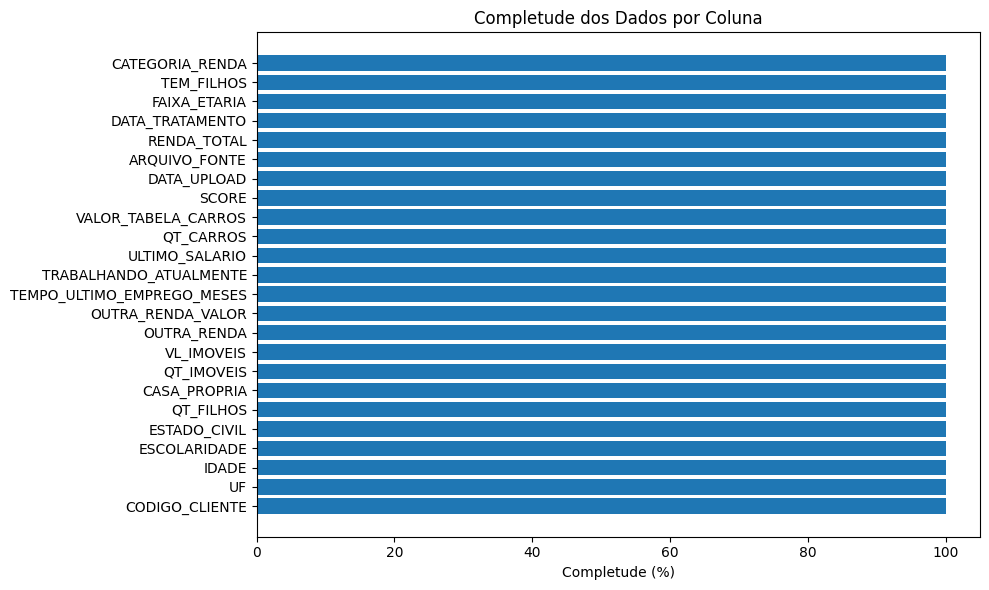

In [6]:
print("5. VISUALIZAÇÃO")
print("-" * 50)
ordered_cols = sorted(completude_por_coluna.items(), key=lambda item: item[1])
labels = [item[0] for item in ordered_cols]
values = [item[1] for item in ordered_cols]
plt.figure(figsize=(10, 6))
plt.barh(labels, values)
plt.xlabel('Completude (%)')
plt.title('Completude dos Dados por Coluna')
plt.tight_layout()
plt.savefig('quality_report.png')
print("Gráfico de qualidade salvo em: quality_report.png")


In [7]:
print("" + "=" * 50)
print("SCORE GERAL DE QUALIDADE")
print("=" * 50)
score_final = (completude_geral + unicidade) / 2
print(f"Score Final: {score_final:.2f}%")
if score_final >= 90:
    print("Classificação: EXCELENTE")
elif score_final >= 80:
    print("Classificação: BOM")
elif score_final >= 70:
    print("Classificação: REGULAR")
else:
    print("Classificação: NECESSITA MELHORIAS")


SCORE GERAL DE QUALIDADE
Score Final: 100.00%
Classificação: EXCELENTE
